In [ ]:
IEEE 802.1q  : VTP  : VLAN Trunking Protocol

In [ ]:
http://www.ktword.co.kr/test/view/view.php?no=2723

In [ ]:
access port : 특정 vlan 번호만 통과 시킨다.

In [ ]:
trunk port : 모든(특정) vlan 번호가 통과 할 수 있다.

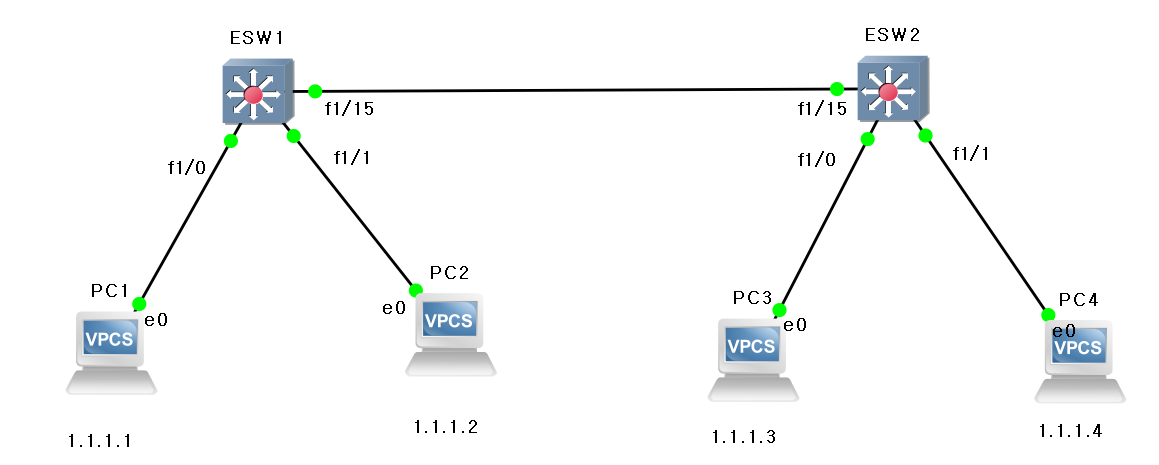

In [ ]:
ESW1#sh vlan-sw bri

VLAN Name                             Status    Ports
---- -------------------------------- --------- -------------------------------
1    default                          active    Fa1/0, Fa1/1, Fa1/2, Fa1/3
                                                Fa1/4, Fa1/5, Fa1/6, Fa1/7
                                                Fa1/8, Fa1/9, Fa1/10, Fa1/11
                                                Fa1/12, Fa1/13, Fa1/14, Fa1/15
1002 fddi-default                     active
1003 token-ring-default               active
1004 fddinet-default                  active
1005 trnet-default                    active
ESW1#

In [ ]:
PC2번을 VLAN 2으로 변경하자.

In [ ]:
1. vlan 2을 생성하자.

In [ ]:
ESW1#vlan da
ESW1(vlan)#vlan 2
VLAN 2 added:
    Name: VLAN0002
ESW1(vlan)#exit
APPLY completed.
Exiting....
ESW1#


In [ ]:
ESW1#sh vlan-sw bri

VLAN Name                             Status    Ports
---- -------------------------------- --------- -------------------------------
1    default                          active    Fa1/0, Fa1/1, Fa1/2, Fa1/3
                                                Fa1/4, Fa1/5, Fa1/6, Fa1/7
                                                Fa1/8, Fa1/9, Fa1/10, Fa1/11
                                                Fa1/12, Fa1/13, Fa1/14, Fa1/15
2    VLAN0002                         active
1002 fddi-default                     active
1003 token-ring-default               active
1004 fddinet-default                  active
1005 trnet-default                    active
ESW1#

In [ ]:
PC2의 연결포트 f1/1 (L2 Port) 기본값 : access 포트이고 vlan 1번이 배정되어 있다.

In [ ]:
2. vlan 2로 변경

In [ ]:
ESW1(config-if)#switchport mode ?
  access  Set trunking mode to ACCESS unconditionally
  trunk   Set trunking mode to TRUNK unconditionally

ESW1(config-if)#switchport mode access
ESW1(config-if)#sw mo acc


In [ ]:
ESW1(config-if)#sw acc vlan 2    <--- vlan 변경 명령어

In [ ]:
ESW1#sh vlan-sw bri

VLAN Name                             Status    Ports
---- -------------------------------- --------- -------------------------------
1    default                          active    Fa1/0, Fa1/2, Fa1/3, Fa1/4
                                                Fa1/5, Fa1/6, Fa1/7, Fa1/8
                                                Fa1/9, Fa1/10, Fa1/11, Fa1/12
                                                Fa1/13, Fa1/14, Fa1/15
2    VLAN0002                         active    Fa1/1
1002 fddi-default                     active
1003 token-ring-default               active
1004 fddinet-default                  active
1005 trnet-default                    active
ESW1#

In [ ]:
과제 : PC4을 VLAN 2에 포함시켜라.
    1.1.1.4

In [ ]:
ESW2#sh vlan-sw bri

VLAN Name                             Status    Ports
---- -------------------------------- --------- -------------------------------
1    default                          active    Fa1/0, Fa1/2, Fa1/3, Fa1/4
                                                Fa1/5, Fa1/6, Fa1/7, Fa1/8
                                                Fa1/9, Fa1/10, Fa1/11, Fa1/12
                                                Fa1/13, Fa1/14, Fa1/15
2    VLAN0002                         active    Fa1/1
1002 fddi-default                     active
1003 token-ring-default               active
1004 fddinet-default                  active
1005 trnet-default                    active
ESW2#


In [ ]:
목표3.  SW - SW 구간에서 모든 vlan이 전부 통신했으면 좋겠다.

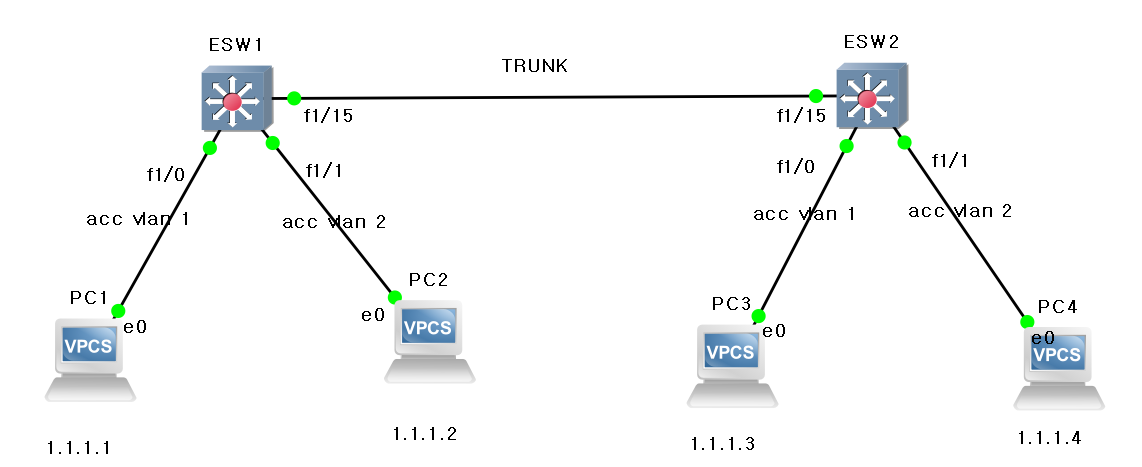

In [ ]:
ESW1(config)#int f1/15
ESW1(config-if)#sw mo tr
ESW1(config-if)#
*Mar  1 00:14:17.707: %DTP-5-TRUNKPORTON: Port Fa1/15 has become dot1q trunk
ESW1(config-if)#sw tr all vlan all
ESW1(config-if)#


In [ ]:
ESW1#sh int tr

Port      Mode         Encapsulation  Status        Native vlan
Fa1/15    on           802.1q         trunking      1

Port      Vlans allowed on trunk
Fa1/15    1-1005

Port      Vlans allowed and active in management domain
Fa1/15    1-2

Port      Vlans in spanning tree forwarding state and not pruned
Fa1/15    1-2
ESW1#

In [ ]:
ESW2#conf t
Enter configuration commands, one per line.  End with CNTL/Z.
ESW2(config)#int f1/15
ESW2(config-if)#sw mo tr
ESW2(config-if)#sw t
*Mar  1 00:12:57.791: %DTP-5-TRUNKPORTON: Port Fa1/15 has become dot1q trunk
ESW2(config-if)#sw tr all vlan all
ESW2(config-if)#end
ESW2#

In [ ]:
연습문제

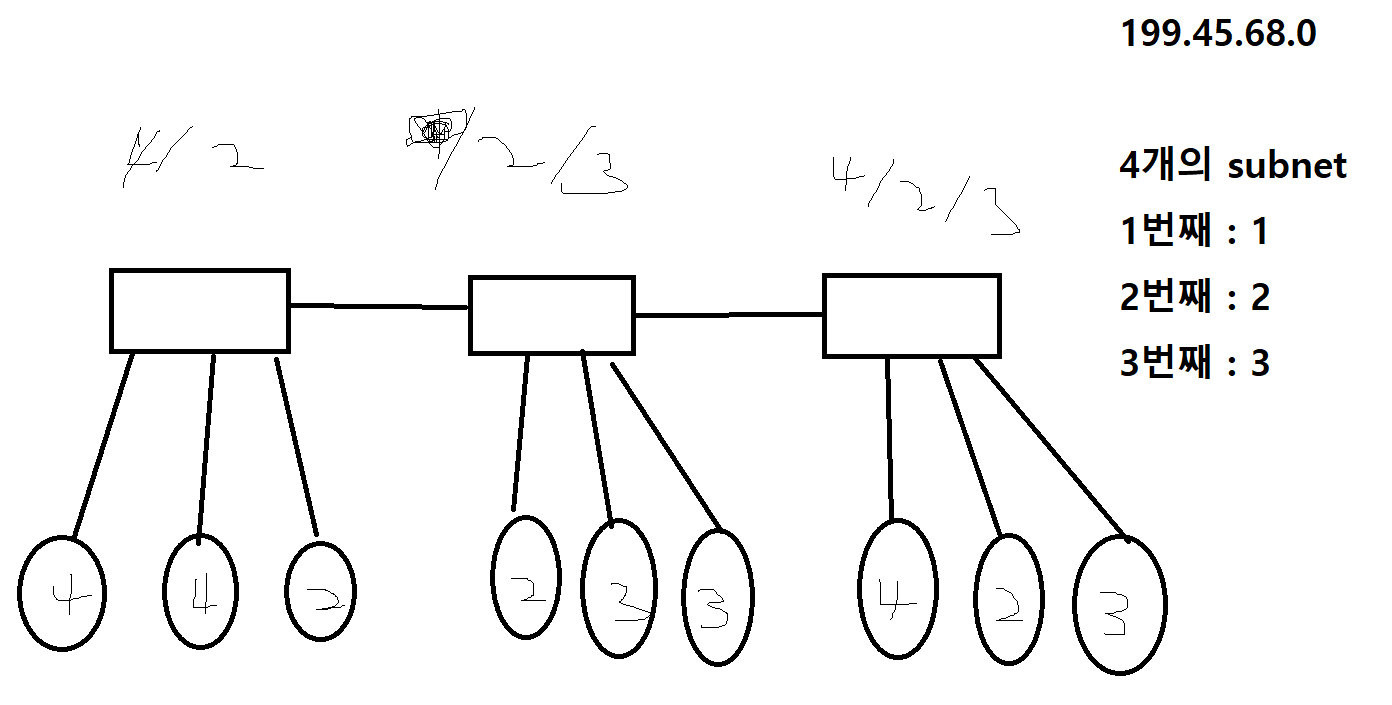

In [ ]:
ESW2#sh vtp status
VTP Version                     : 2
Configuration Revision          : 2
Maximum VLANs supported locally : 68
Number of existing VLANs        : 7
VTP Operating Mode              : Server
VTP Domain Name                 :
VTP Pruning Mode                : Disabled
VTP V2 Mode                     : Disabled
VTP Traps Generation            : Disabled
MD5 digest                      : 0x70 0x97 0x04 0x90 0x23 0x7D 0x9B 0x13
Configuration last modified by 0.0.0.0 at 3-1-02 00:03:47
Local updater ID is 0.0.0.0 (no valid interface found)
ESW2#

In [ ]:
VTP Pruning Mode                : Disabled

In [ ]:
Pruning  ---> VTP --> 스위치 자신이 갖고 있는 vlan정보
                                            --------   vlan.dat 별도 저장됨.

In [ ]:
각 스위치는 Trunk 포트를 이용하여 vlan 정보를 교환한다.

In [ ]:
10   VLAN0010                         active    Fa1/3

ESW1#conf t
Enter configuration commands, one per line.  End with CNTL/Z.
ESW1(config)#int f1/3
ESW1(config-if)#ip add 192.168.0.30 255.255.255.0

% IP addresses may not be configured on L2 links.

ESW1(config-if)#

In [ ]:
f1/3에 IP 를 등록하려 했으나 실패했다. ---> 이유? L2 포트에는 IP를 사용할 수 없다.

In [ ]:
vlan ---> 가상 인터페이스 생성 가능

In [ ]:
Fa1/3 -- VLAN0010  -- 192.168.0.30 255.255.255.0

In [ ]:
ESW1(config)#int vlan 10
ESW1(config-if)#
*Mar  1 01:33:50.443: %LINEPROTO-5-UPDOWN: Line protocol on Interface Vlan10, changed state to up
ESW1(config-if)#ip add 192.168.0.30 255.255.255.0
ESW1(config-if)#

In [ ]:
conf t
int f1/3
sw mo acc
sw acc vlan 10

In [ ]:
ESW1#ping 192.168.0.1

Type escape sequence to abort.
Sending 5, 100-byte ICMP Echos to 192.168.0.1, timeout is 2 seconds:
!!!!!
Success rate is 100 percent (5/5), round-trip min/avg/max = 60/262/1044 ms
ESW1#


In [ ]:
Inter-VLAN

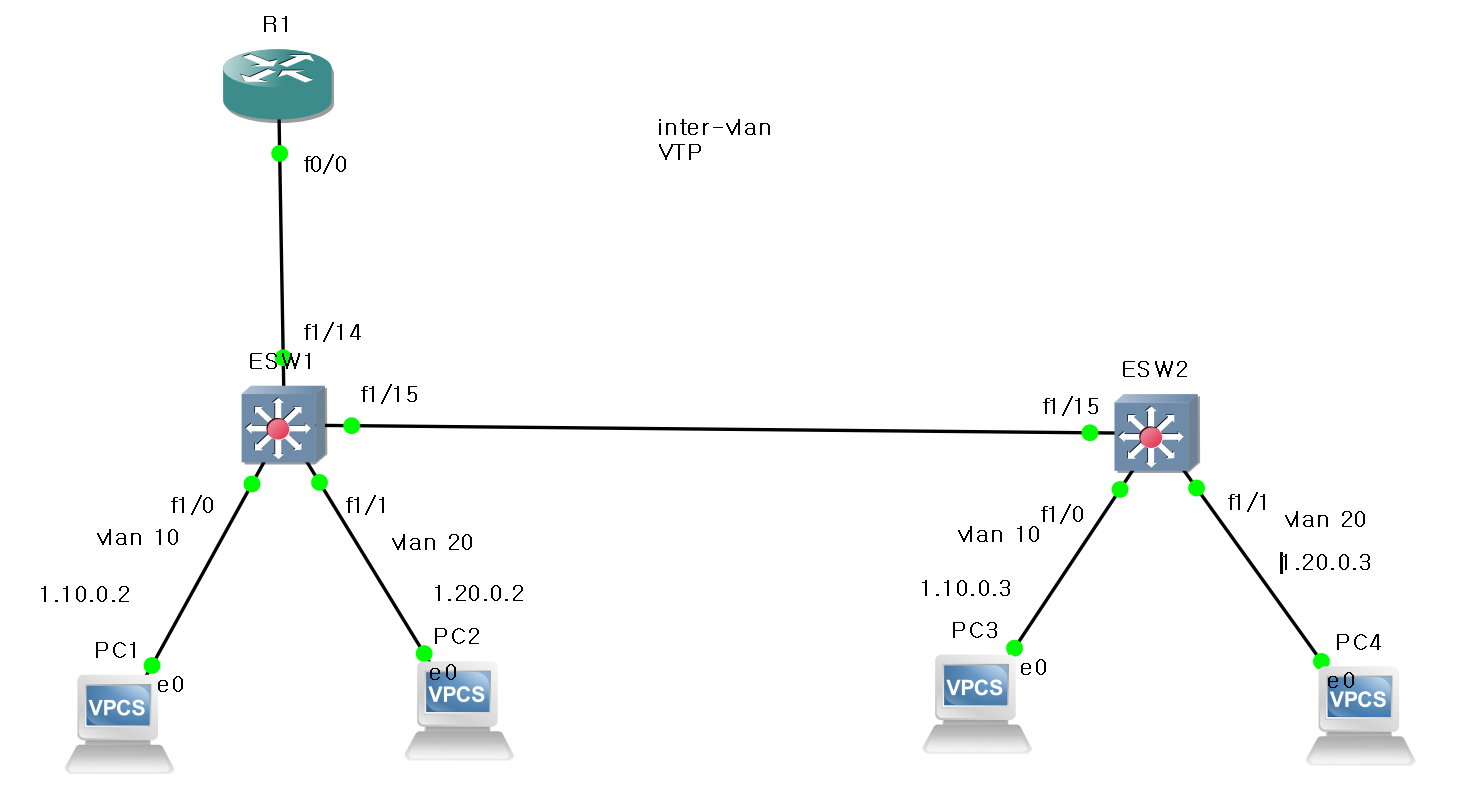

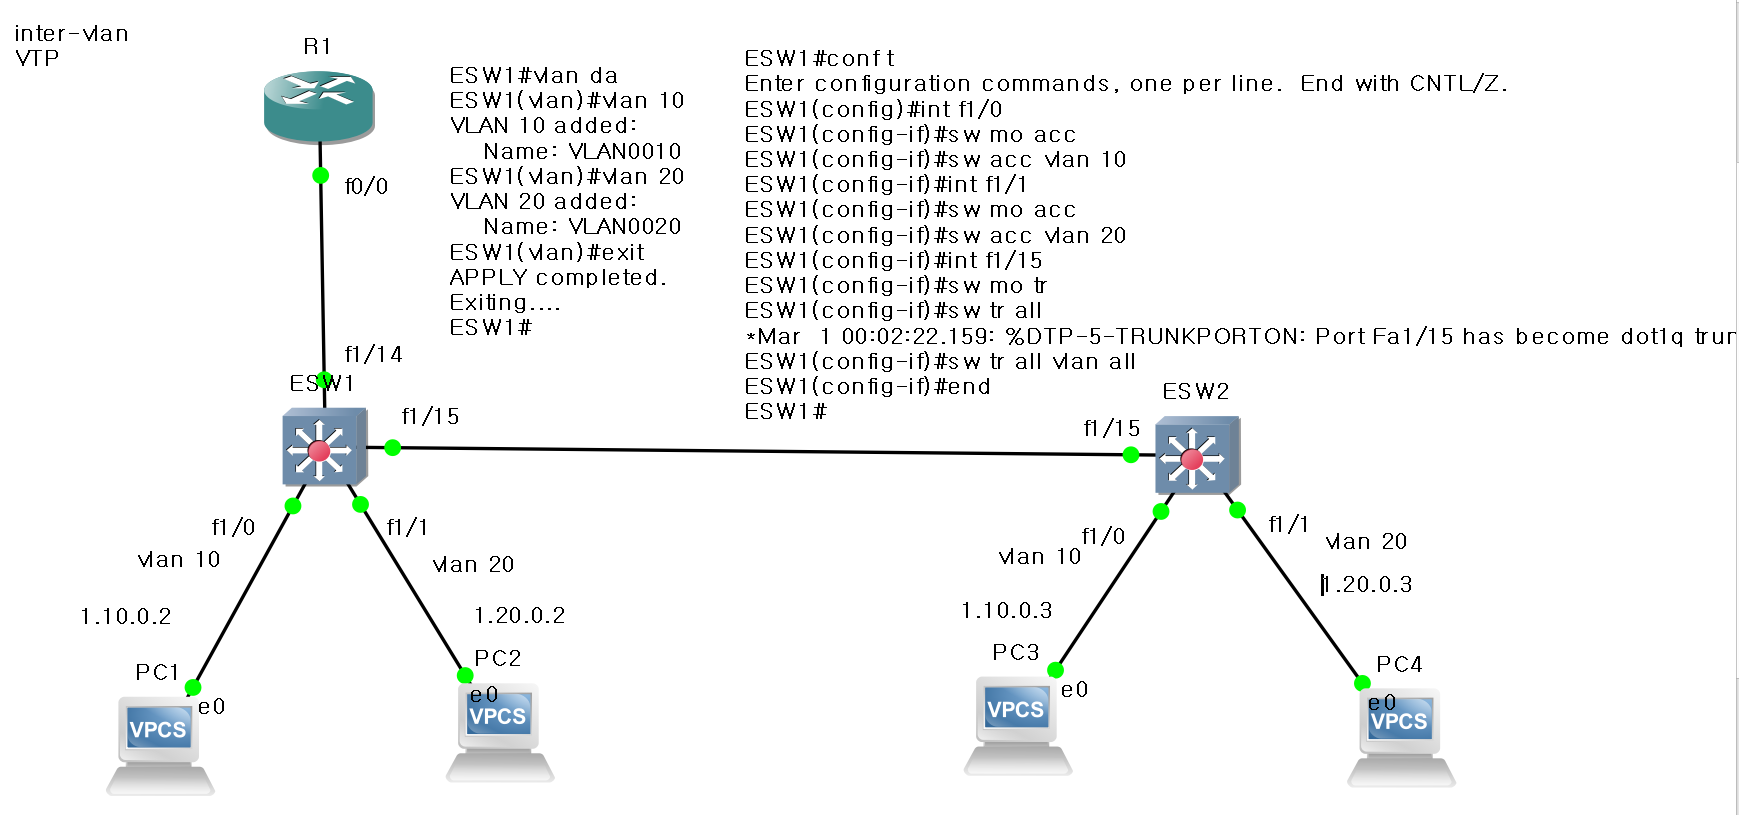

In [ ]:
인터VLAN을 사용하기 위한 조건

In [ ]:
1. 라우터에서 VLAN 프로토콜(dot1q) : IEEE 802.1Q
   활성화 시키고 vlan 10 / vlan 20을 적용시켜줘야 한다.

In [ ]:
2. 라우터 역할의 본질인 GW의 역할을 수행해야 한다.
                    vlan 10 : 1.10.0.1 255.255.255.0
                    vlan 20 : 1.20.0.1 255.255.255.0

In [ ]:
ESW1(config)#int f1/14
ESW1(config-if)#sw mo tr
ESW1(config-if)#sw
*Mar  1 00:16:53.179: %DTP-5-TRUNKPORTON: Port Fa1/14 has become dot1q trunk
ESW1(config-if)#sw tr all vlan all
ESW1(config-if)#end

In [ ]:
라우터 설정

In [ ]:
int f0/0.10
        ---   : Sub Interface : 물리 인터페이스인 f0/0을 가상으로 나눈 인터페이스

In [ ]:
R1(config)#int f0/0.10
R1(config-subif)#

In [ ]:
encapsulation : (대상 패킷) : 감싸는 행위 : 캡슐화

In [ ]:
R1(config-subif)#encapsulation dot1Q 10
                 -------------         : 동작 프로토콜을 선언
                               -----   : vlan (vtp) 프로토콜
                                     --  : f0/0.10 인터페이스를 vlan 10 에 포함

In [ ]:
R1(config)#int f0/0.10
R1(config-subif)#encapsulation dot1Q 10
R1(config-subif)#ip add 1.10.0.1 255.255.255.0
R1(config-subif)#no sh
R1(config-subif)#


In [ ]:
PC1> ping 1.10.0.1
84 bytes from 1.10.0.1 icmp_seq=1 ttl=255 time=15.898 ms
84 bytes from 1.10.0.1 icmp_seq=2 ttl=255 time=16.019 ms
84 bytes from 1.10.0.1 icmp_seq=3 ttl=255 time=16.129 ms
84 bytes from 1.10.0.1 icmp_seq=4 ttl=255 time=15.662 ms
84 bytes from 1.10.0.1 icmp_seq=5 ttl=255 time=14.812 ms

PC1> ip 1.10.0.2 255.255.255.0 1.10.0.1
Checking for duplicate address...
PC1 : 1.10.0.2 255.255.255.0 gateway 1.10.0.1

PC1>


In [ ]:
     1.0.0.0/24 is subnetted, 1 subnets
C       1.10.0.0 is directly connected, FastEthernet0/0.10
R1#

In [ ]:
R1(config)#int f0/0.20
R1(config-subif)#enc do 20
R1(config-subif)#ip add 1.20.0.1 255.255.255.0
R1(config-subif)#


In [ ]:
     1.0.0.0/24 is subnetted, 2 subnets
C       1.10.0.0 is directly connected, FastEthernet0/0.10
C       1.20.0.0 is directly connected, FastEthernet0/0.20
R1#


In [ ]:
VTP : VLAN Tansper Protocol
           Tansport

In [ ]:
VLAN 정보를 전달하는 프로토콜

In [ ]:
이미 각 스위치는 VLAN정보(vlan.dat) 파일을 TRUNK 포트를 이용하여 전달하고 있다.

In [ ]:
ESW1#sh vtp status
VTP Version                     : 2
Configuration Revision          : 1
Maximum VLANs supported locally : 68
Number of existing VLANs        : 7
VTP Operating Mode              : Server
VTP Domain Name                 :
VTP Pruning Mode                : Disabled
VTP V2 Mode                     : Disabled
VTP Traps Generation            : Disabled
MD5 digest                      : 0xF5 0xC8 0x51 0x28 0x86 0xBD 0x62 0x26
Configuration last modified by 0.0.0.0 at 3-1-02 00:01:44
Local updater ID is 0.0.0.0 (no valid interface found)
ESW1#


In [ ]:
VTP Version --> 1 ~ 3 : 높을 수록 고급 장비

In [ ]:
Configuration Revision :   1++   : vlan정보가 수정될 때마다 1씩 증가한다.

In [ ]:
Maximum VLANs supported locally  : 자체 사용 VLAN

In [ ]:
Number of existing VLANs : 현재 사용중인 VLAN의 갯수

In [ ]:
VTP 정보를 동기화하면 어떨까???

In [ ]:
VTP Operating Mode              : Server
VTP Domain Name                 :


In [ ]:
VTP Operating Mode --> Server
                       Client
                       Transparent (투명)

In [ ]:
Server ---> VLAN 생성/수정/삭제

In [ ]:
Client ---> VLAN 생성/수정/삭제 X
            Server가 보내준 vlan.dat 자신의 vlan-DB에 동기화
            Server가 보내준 vlan.dat Trunk 포트를 통해 다른 스위치에 전달

In [ ]:
Transparent --> VLAN 생성/수정/삭제
                Server가 보내준 vlan.dat 자신의 vlan-DB에 동기화 X
                Server가 보내준 vlan.dat Trunk 포트를 통해 다른 스위치에 전달

In [ ]:
동기화 : Server가 보내준 정보를 자신의 DB에 적용한다.

In [ ]:
보안책 : 도메인정보가 같아야한다.
         동기화 패스워드 지정한다.

In [ ]:
VTP 설정

In [ ]:
1. 도메인 주소 설정

In [ ]:
vlan database
vtp domain kong.com

In [ ]:
2. VTP간에 사용할 패스워드 지정

In [ ]:
vlan database
vtp password cisco

In [ ]:
3. VTP 동작 모드 설정(기본 : server 모드)

In [ ]:
vtp server
vtp client
vtp transparent 

In [ ]:
ESW1 설정

In [ ]:
ESW1(vlan)#vtp domain kong.com
Changing VTP domain name from NULL to kong.com
ESW1(vlan)#vtp password cisco
Setting device VLAN database password to cisco.
ESW1(vlan)#vtp server
Device mode already VTP SERVER.
ESW1(vlan)#

In [ ]:
ESW2 설정

In [ ]:
ESW2#vlan da
ESW2(vlan)#vtp domain kong.com
Domain name already set to kong.com .
ESW2(vlan)#vtp password cisco
Setting device VLAN database password to cisco.
ESW2(vlan)#vtp client
Setting device to VTP CLIENT mode.
ESW2(vlan)#

In [ ]:
ESW2#vlan da
ESW2(vlan)#vlan 10
VLAN 10 added:
    Name: VLAN0010
ESW2(vlan)#exit
In CLIENT state, no apply attempted.
Exiting....
ESW2#


In [ ]:
테스트

In [ ]:
ESW1#vlan da
ESW1(vlan)#vlan 10
VLAN 10 added:
    Name: VLAN0010
ESW1(vlan)#vlan 20
VLAN 20 added:
    Name: VLAN0020
ESW1(vlan)#exit
APPLY completed.
Exiting....
ESW1#
